# Классификация уровня ожирения

**Данные:** UCI *Estimation of obesity levels based on eating habits and physical condition* — 2111 анкет, 16 признаков
(пол, возраст, рост, вес, пищевые привычки, активность, транспорт), целевая переменная `NObeyesdad` — 7 классов
от `Insufficient_Weight` до `Obesity_Type_III`.

**Метрика:** F1 macro — классы почти сбалансированы, а важно одинаково хорошее качество на каждом классе.

**Проверяемые гипотезы**

| # | Гипотеза |
|---|---|
| 1 | L2 (Ridge) даст качество выше, чем L1 (Lasso) |
| 2 | Порядковое кодирование CAEC/CALC (меньше признаков) не хуже one-hot |
| 3 | ElasticNet как компромисс L1 и L2 окажется лучше каждой из них по отдельности |
| 4 | Оценки на кросс-валидации согласуются с отложенным тестом (нет переобучения) |
| 5 | F1 у «средних» классов (Normal, Overweight I–II) ниже, чем у крайних — у них соседи с обеих сторон шкалы |
| 6 | Отбор 10 самых информативных признаков не ухудшит качество |
| 7 | Подбор гиперпараметров ансамблей деревьев даст прирост больше разброса между фолдами |

**Принципы сравнения**

* модели сравниваются по кросс-валидации на одних и тех же фолдах: среднее ± стандартное отклонение;
  разница меньше разброса между фолдами не считается различием;
* у всех сравниваемых логистических регрессий одинаковый solver и `max_iter`, сходимость проверяется по `n_iter_`;
* предупреждения о несходимости не отключаются;
* масштабирование и отбор признаков в новых экспериментах — внутри `Pipeline`, чтобы на CV они обучались только на train-фолде.

**План:** EDA → дубликаты и признак BMI → подготовка (ordinal) → регуляризации: OvR против multinomial →
честное сравнение L1/L2/ElasticNet → отбор признаков → one-hot → нелинейные модели и BMI → подбор гиперпараметров → образ жизни без роста и веса → ошибки по классам → итоговая модель на тесте → итоги.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

RANDOM_STATE = 42

C:\Users\User\anaconda3\lib\site-packages\pandas\core\computation\expressions.py:20: UserWarning: Pandas requires version '2.7.3' or newer of 'numexpr' (version '2.7.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
import pandas as pd
import sklearn
print('sklearn', sklearn.__version__, '| pandas', pd.__version__, '| numpy', np.__version__)

DATA_PATH = 'ObesityDataSet_raw_and_data_sinthetic.csv'   # файл с данными лежит рядом с ноутбуком
df = pd.read_csv(DATA_PATH)
df.head()

sklearn 1.3.2 | pandas 2.0.3 | numpy 1.24.4


,Age,Gender,Height,Weight,CALC,FAVC,FCVC,NCP,SCC,SMOKE,CH2O,family_history_with_overweight,FAF,TUE,CAEC,MTRANS,NObeyesdad
0,21.0,Female,1.62,64.0,no,no,2.0,3.0,no,no,2.0,yes,0.0,1.0,Sometimes,Public_Transportation,Normal_Weight
1,21.0,Female,1.52,56.0,Sometimes,no,3.0,3.0,yes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,23.0,Male,1.80,77.0,Frequently,no,2.0,3.0,no,no,2.0,yes,2.0,1.0,Sometimes,Public_Transportation,Normal_Weight
3,27.0,Male,1.80,87.0,Frequently,no,3.0,3.0,no,no,2.0,no,2.0,0.0,Sometimes,Walking,Overweight_Level_I
4,22.0,Male,1.78,89.8,Sometimes,no,2.0,1.0,no,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [3]:
df.shape          
df.info()         
df.isnull().sum()
#df['NObeyesdad'].unique()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Age                             2111 non-null   float64
 1   Gender                          2111 non-null   object 
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   CALC                            2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   SCC                             2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  family_history_with_overweight  2111 non-null   object 
 12  FAF                             21

Age                               0
Gender                            0
Height                            0
Weight                            0
CALC                              0
FAVC                              0
FCVC                              0
NCP                               0
SCC                               0
SMOKE                             0
CH2O                              0
family_history_with_overweight    0
FAF                               0
TUE                               0
CAEC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64

Gender: Feature, Categorical, "Gender"
Age : Feature, Continuous, "Age"
Height: Feature, Continuous
Weight: Feature Continuous
family_history_with_overweight: Feature, Binary, " Has a family member suffered or suffers from overweight? "
FAVC : Feature, Binary, " Do you eat high caloric food frequently? "
FCVC : Feature, Integer, " Do you usually eat vegetables in your meals? "
NCP : Feature, Continuous, " How many main meals do you have daily? "
CAEC : Feature, Categorical, " Do you eat any food between meals? "
SMOKE : Feature, Binary, " Do you smoke? "
CH2O: Feature, Continuous, " How much water do you drink daily? "
SCC: Feature, Binary, " Do you monitor the calories you eat daily? "
FAF: Feature, Continuous, " How often do you have physical activity? "
TUE : Feature, Integer, " How much time do you use technological devices such as cell phone, videogames, television, computer and others? "
CALC : Feature, Categorical, " How often do you drink alcohol? "
MTRANS : Feature, Categorical, " Which transportation do you usually use? "
NObeyesdad : Target, Categorical, "Obesity level"

## Дубликаты

Синтетическая часть датасета содержит полные копии строк. При случайном разбиении копия может попасть
и в train, и в test — тогда модель видит тестовый объект при обучении и оценка завышается.
Поэтому дубликаты удаляются до любого разбиения.

In [4]:
n_dup = df.duplicated().sum()
print(f'Полных дубликатов строк: {n_dup} из {len(df)} ({100 * n_dup / len(df):.1f}%)')
df = df.drop_duplicates().reset_index(drop=True)
print('После удаления:', df.shape)

Полных дубликатов строк: 24 из 2111 (1.1%)
После удаления: (2087, 17)


In [5]:
from sklearn.preprocessing import LabelEncoder

binary_cols = ['Gender', 'family_history_with_overweight', 'FAVC', 'SMOKE', 'SCC']

encoders = {} 

for col in binary_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le
    print(f"{col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# Целевую переменную кодируем отдельно и обязательно сохраняем энкодер
le_target = LabelEncoder()
df['NObeyesdad_encoded'] = le_target.fit_transform(df['NObeyesdad'])
print("NObeyesdad:", dict(zip(le_target.classes_, le_target.transform(le_target.classes_))))

Gender: {'Female': 0, 'Male': 1}
family_history_with_overweight: {'no': 0, 'yes': 1}
FAVC: {'no': 0, 'yes': 1}
SMOKE: {'no': 0, 'yes': 1}
SCC: {'no': 0, 'yes': 1}
NObeyesdad: {'Insufficient_Weight': 0, 'Normal_Weight': 1, 'Obesity_Type_I': 2, 'Obesity_Type_II': 3, 'Obesity_Type_III': 4, 'Overweight_Level_I': 5, 'Overweight_Level_II': 6}


In [6]:
df.describe().round(2)

,Age,Gender,Height,Weight,FAVC,FCVC,NCP,SCC,SMOKE,CH2O,family_history_with_overweight,FAF,TUE,NObeyesdad_encoded
count,2087.00,2087.0,2087.00,2087.00,2087.00,2087.00,2087.00,2087.00,2087.00,2087.00,2087.00,2087.00,2087.00,2087.00
mean,24.35,0.5,1.70,86.86,0.88,2.42,2.70,0.05,0.02,2.00,0.83,1.01,0.66,3.01
std,6.37,0.5,0.09,26.19,0.32,0.53,0.76,0.21,0.14,0.61,0.38,0.85,0.61,1.95
min,14.00,0.0,1.45,39.00,0.00,1.00,1.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00
25%,19.92,0.0,1.63,66.00,1.00,2.00,2.70,0.00,0.00,1.59,1.00,0.12,0.00,1.00
50%,22.85,1.0,1.70,83.10,1.00,2.40,3.00,0.00,0.00,2.00,1.00,1.00,0.63,3.00
75%,26.00,1.0,1.77,108.02,1.00,3.00,3.00,0.00,0.00,2.47,1.00,1.68,1.00,5.00
max,61.00,1.0,1.98,173.00,1.00,3.00,4.00,1.00,1.00,3.00,1.00,3.00,2.00,6.00


# Распределение классов

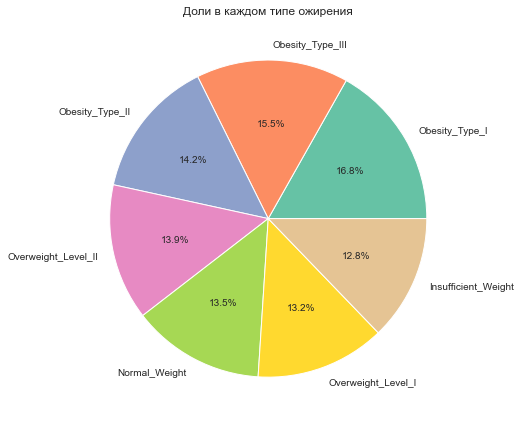

In [7]:
target_col = 'NObeyesdad'

fig, ax = plt.subplots(figsize=(8, 6))

df[target_col].value_counts(normalize=True).plot.pie(
    ax=ax,
    autopct='%1.1f%%',
    colors=sns.color_palette('Set2')
)

ax.set_ylabel('')
ax.set_title('Доли в каждом типе ожирения')

plt.tight_layout()
plt.show()

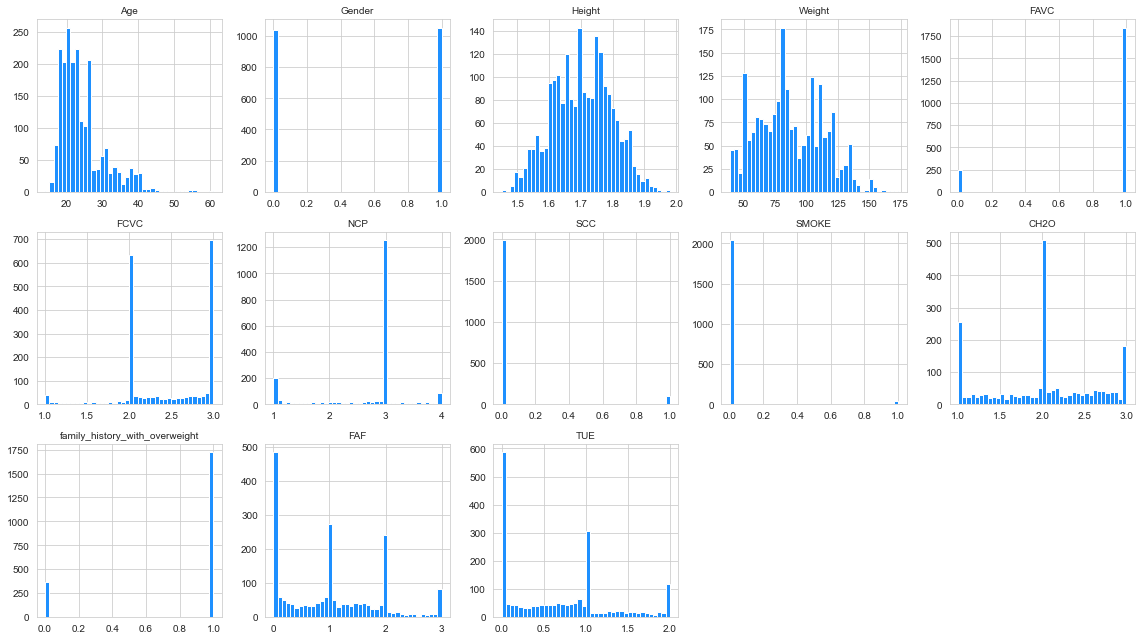

    Age  Gender  Height  Weight        CALC  FAVC  FCVC  NCP  SCC  SMOKE  \
0  21.0       0    1.62    64.0          no     0   2.0  3.0    0      0   
1  21.0       0    1.52    56.0   Sometimes     0   3.0  3.0    1      1   
2  23.0       1    1.80    77.0  Frequently     0   2.0  3.0    0      0   
3  27.0       1    1.80    87.0  Frequently     0   3.0  3.0    0      0   
4  22.0       1    1.78    89.8   Sometimes     0   2.0  1.0    0      0   

   CH2O  family_history_with_overweight  FAF  TUE       CAEC  \
0   2.0                               1  0.0  1.0  Sometimes   
1   3.0                               1  3.0  0.0  Sometimes   
2   2.0                               1  2.0  1.0  Sometimes   
3   2.0                               0  2.0  0.0  Sometimes   
4   2.0                               0  0.0  0.0  Sometimes   

                  MTRANS           NObeyesdad  NObeyesdad_encoded  
0  Public_Transportation        Normal_Weight                   1  
1  Public_Transportati

In [8]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
exclude_cols = ['NObeyesdad_encoded']
numeric_cols = [col for col in numeric_cols if col not in exclude_cols]

n_cols = len(numeric_cols)
n_rows = (n_cols + 3) // 5
fig, axes = plt.subplots(n_rows, 5, figsize=(16, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    df[col].hist(bins=40, ax=axes[i], color='#1E90FF', edgecolor='white')
    axes[i].set_title(col, fontsize=10)

for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()
print(df.head())

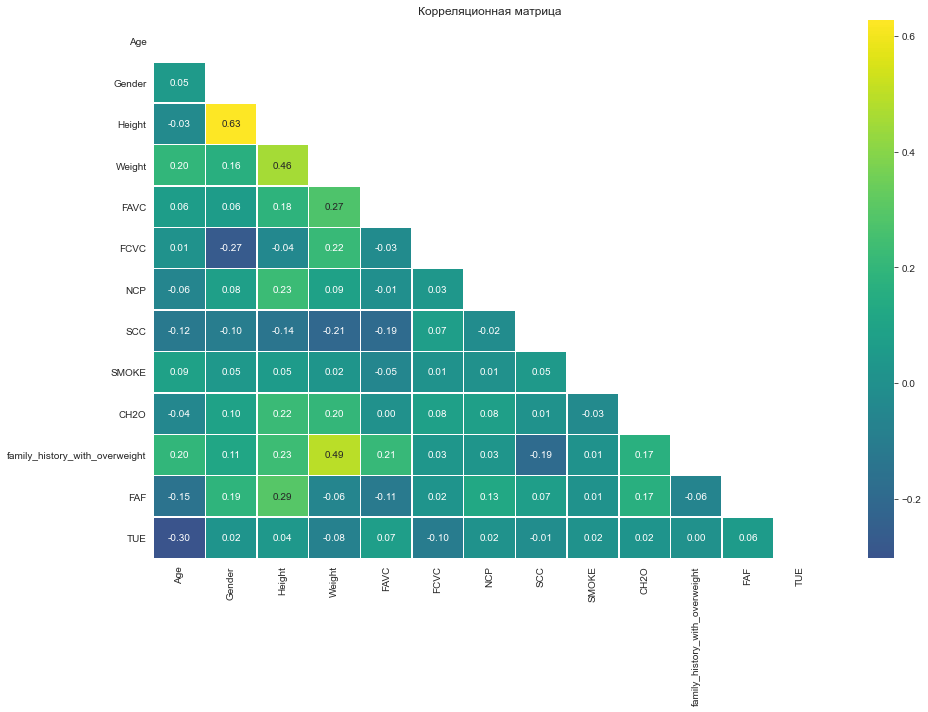

In [9]:
plt.figure(figsize=(14, 10))
corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='viridis', center=0, linewidths=0.5)
plt.title('Корреляционная матрица')
plt.tight_layout()
plt.show()

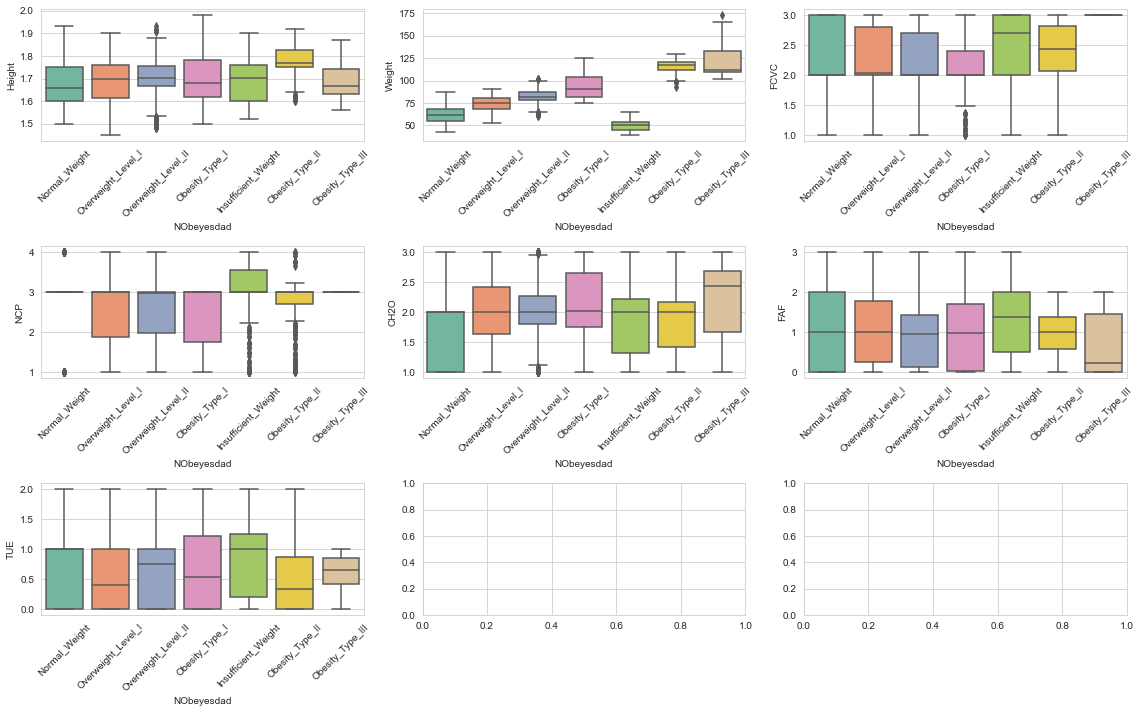

In [10]:
fig, axes = plt.subplots(3, 3, figsize=(16, 10))
top_features = ['Height', 'Weight', 'FCVC','NCP', 'CH2O', 'FAF', 'TUE']
for idx, col in enumerate(top_features):
    ax = axes[idx // 3][idx % 3]
    sns.boxplot(data=df, x=target_col, y=col, ax=ax, palette='Set2')
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## Индекс массы тела

По корреляционной матрице и боксплотам главный признак - `Weight`, а `Height` сам по себе с классом почти не связан.
Но уровень ожирения по определению задаётся индексом массы тела BMI = Weight / Height², то есть рост важен
**в паре** с весом. Проверим, насколько метка в этом датасете совпадает с порогами BMI.

Признак считаем отдельно и в базовые модели пока не добавляем - его вклад оценим в разделе про нелинейные модели.

,n,min,q25,median,q75,max
NObeyesdad,,,,,,
Insufficient_Weight,267,13.00,17.07,17.53,17.90,19.08
Normal_Weight,282,18.49,20.59,22.12,23.70,24.91
Overweight_Level_I,276,22.83,25.56,25.95,26.31,28.77
Overweight_Level_II,290,25.71,27.61,28.15,28.89,30.36
Obesity_Type_I,351,29.91,31.37,32.20,32.97,35.17
Obesity_Type_II,297,34.05,35.75,36.42,37.88,39.79
Obesity_Type_III,324,36.77,40.59,41.94,43.84,50.81


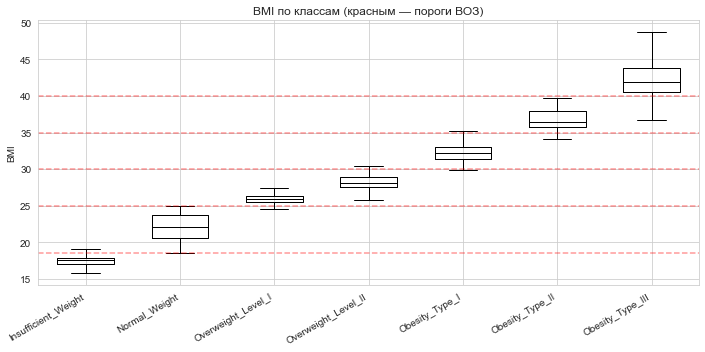

In [11]:
bmi = df['Weight'] / df['Height'] ** 2

order = ['Insufficient_Weight', 'Normal_Weight', 'Overweight_Level_I', 'Overweight_Level_II',
         'Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III']

bmi_stats = (bmi.groupby(df['NObeyesdad'])
                .agg(n='count', min='min', q25=lambda s: s.quantile(.25), median='median',
                     q75=lambda s: s.quantile(.75), max='max')
                .reindex(order).round(2))
display(bmi_stats)

fig, ax = plt.subplots(figsize=(10, 5))
ax.boxplot([bmi[df['NObeyesdad'] == c].values for c in order],
           showfliers=False, widths=0.6, medianprops=dict(color='black'))
ax.set_xticks(range(1, len(order) + 1))
ax.set_xticklabels(order, rotation=30, ha='right')
for thr in (18.5, 25, 30, 35, 40):
    ax.axhline(thr, color='red', linestyle='--', alpha=.4)
ax.set_ylabel('BMI')
ax.set_title('BMI по классам (красным — пороги ВОЗ)')
plt.tight_layout(); plt.show()

In [12]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.tree import DecisionTreeClassifier

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for name, feats in (('только BMI', bmi.to_frame('BMI')),
                    ('Height + Weight', df[['Height', 'Weight']]),
                    ('только Weight', df[['Weight']])):
    sc = cross_validate(DecisionTreeClassifier(max_depth=7, random_state=RANDOM_STATE),
                        feats, df['NObeyesdad'], cv=cv, scoring='f1_macro')
    print(f"Дерево, {name:16s}: F1 macro = {sc['test_score'].mean():.3f} ± {sc['test_score'].std():.3f}")

Дерево, только BMI      : F1 macro = 0.948 ± 0.010
Дерево, Height + Weight : F1 macro = 0.903 ± 0.006
Дерево, только Weight   : F1 macro = 0.663 ± 0.020


**Вывод.** Медианы BMI строго растут от Insufficient_Weight к Obesity_Type_III, а межквартильные интервалы соседних классов не пересекаются. Границы между классами проходят около порогов ВОЗ 18.5, 30 и 35. У порогов 25 и 40 есть отдельные объекты, далеко заходящие в соседний класс: Overweight_Level_I от 22.8, Obesity_Type_III от 36.8. Категорию «избыточный вес» датасет делит на два уровня примерно по BMI ≈ 27, хотя у ВОЗ такого порога нет.

Дерево решений на одном признаке BMI предсказывает класс с F1 macro = 0.948 ± 0.010, на паре Height + Weight - 0.903 ± 0.006, на одном весе - 0.663 ± 0.020. Значит, класс почти полностью определяется индексом массы тела, и задача в основном сводится к восстановлению формулы Weight / Height². Это нужно учитывать дальше: признаки образа жизни могут добавить к качеству немного, а высокие метрики объясняются прежде всего парой Height + Weight.

## Подготовка признаков: порядковое кодирование

In [13]:
categorical_multi = ['MTRANS']

for col in categorical_multi:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())
    print(df[col].value_counts(normalize=True).round(3) * 100, '%')


--- MTRANS ---
MTRANS
Public_Transportation    1558
Automobile                456
Walking                    55
Motorbike                  11
Bike                        7
Name: count, dtype: int64
MTRANS
Public_Transportation    74.7
Automobile               21.8
Walking                   2.6
Motorbike                 0.5
Bike                      0.3
Name: proportion, dtype: float64 %


In [14]:
order_map = {'no': 0, 'Sometimes': 1, 'Frequently': 2, 'Always': 3}

df_ordinal = df.copy()
df_ordinal['CAEC'] = df_ordinal['CAEC'].map(order_map)
df_ordinal['CALC'] = df_ordinal['CALC'].map(order_map)

print("NaN в CAEC:", df_ordinal['CAEC'].isnull().sum())
print("NaN в CALC:", df_ordinal['CALC'].isnull().sum())
df_ordinal[['CAEC', 'CALC']].head()

NaN в CAEC: 0
NaN в CALC: 0


,CAEC,CALC
0,1,0
1,1,1
2,1,2
3,1,2
4,1,1


In [15]:
df_ordinal = pd.get_dummies(df_ordinal, columns=['MTRANS'], prefix='MTRANS')

print(df_ordinal.columns.tolist())
df_ordinal.head()

['Age', 'Gender', 'Height', 'Weight', 'CALC', 'FAVC', 'FCVC', 'NCP', 'SCC', 'SMOKE', 'CH2O', 'family_history_with_overweight', 'FAF', 'TUE', 'CAEC', 'NObeyesdad', 'NObeyesdad_encoded', 'MTRANS_Automobile', 'MTRANS_Bike', 'MTRANS_Motorbike', 'MTRANS_Public_Transportation', 'MTRANS_Walking']


,Age,Gender,Height,Weight,CALC,FAVC,FCVC,NCP,SCC,SMOKE,...,FAF,TUE,CAEC,NObeyesdad,NObeyesdad_encoded,MTRANS_Automobile,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking
0,21.0,0,1.62,64.0,0,0,2.0,3.0,0,0,...,0.0,1.0,1,Normal_Weight,1,False,False,False,True,False
1,21.0,0,1.52,56.0,1,0,3.0,3.0,1,1,...,3.0,0.0,1,Normal_Weight,1,False,False,False,True,False
2,23.0,1,1.80,77.0,2,0,2.0,3.0,0,0,...,2.0,1.0,1,Normal_Weight,1,False,False,False,True,False
3,27.0,1,1.80,87.0,2,0,3.0,3.0,0,0,...,2.0,0.0,1,Overweight_Level_I,5,False,False,False,False,True
4,22.0,1,1.78,89.8,1,0,2.0,1.0,0,0,...,0.0,0.0,1,Overweight_Level_II,6,False,False,False,True,False


In [16]:
X = df_ordinal.drop(columns=['NObeyesdad', 'NObeyesdad_encoded'], errors='ignore')
y = df_ordinal['NObeyesdad_encoded']  

print(X.shape, y.shape)
print(X.dtypes)  

(2087, 20) (2087,)
Age                               float64
Gender                              int32
Height                            float64
Weight                            float64
CALC                                int64
FAVC                                int32
FCVC                              float64
NCP                               float64
SCC                                 int32
SMOKE                               int32
CH2O                              float64
family_history_with_overweight      int32
FAF                               float64
TUE                               float64
CAEC                                int64
MTRANS_Automobile                    bool
MTRANS_Bike                          bool
MTRANS_Motorbike                     bool
MTRANS_Public_Transportation         bool
MTRANS_Walking                       bool
dtype: object


In [17]:
from sklearn.model_selection import train_test_split

X_train_1, X_test_1, y_train_1, y_test_1 = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train:", X_train_1.shape, "Test:", X_test_1.shape)
print(y_train_1.value_counts(normalize=True).round(3))
print(y_test_1.value_counts(normalize=True).round(3))

Train: (1669, 20) Test: (418, 20)
NObeyesdad_encoded
2    0.168
4    0.155
3    0.142
6    0.139
1    0.135
5    0.132
0    0.128
Name: proportion, dtype: float64
NObeyesdad_encoded
2    0.167
4    0.156
3    0.144
6    0.139
1    0.136
5    0.132
0    0.127
Name: proportion, dtype: float64


In [18]:
from sklearn.preprocessing import StandardScaler

numeric_cols = ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']

scaler = StandardScaler()
X_train_1_scaled = X_train_1.copy()
X_test_1_scaled = X_test_1.copy()

X_train_1_scaled[numeric_cols] = scaler.fit_transform(X_train_1[numeric_cols])
X_test_1_scaled[numeric_cols] = scaler.transform(X_test_1[numeric_cols])  

In [19]:
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score, cross_validate, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.feature_selection import SelectKBest, f_classif, RFE, SelectFromModel
from sklearn.metrics import (classification_report, f1_score, accuracy_score, confusion_matrix,
                             ConfusionMatrixDisplay)

MAX_ITER = 5000   

## Гипотезы 1 и 3: L2 vs L1 vs ElasticNet

Первый запуск: чистые L1 и L2 доступны в `liblinear`, ElasticNet — только в `saga`.

In [20]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_l2_1 = GridSearchCV(
    LogisticRegression(penalty='l2', solver='liblinear', max_iter=MAX_ITER, random_state=42),
    {'C': [0.01, 0.1, 1, 10, 100, 150, 250, 500, 750, 1000, 1500]}, cv=cv, scoring='f1_macro', n_jobs=-1, return_train_score=True
).fit(X_train_1_scaled, y_train_1)

grid_l1_1 = GridSearchCV(
    LogisticRegression(penalty='l1', solver='liblinear', max_iter=MAX_ITER, random_state=42),
    {'C': [0.01, 0.1, 1, 10, 20, 50, 100]}, cv=cv, scoring='f1_macro', n_jobs=-1, return_train_score=True
).fit(X_train_1_scaled, y_train_1)

grid_en_1 = GridSearchCV(
    LogisticRegression(penalty='elasticnet', solver='saga', max_iter=MAX_ITER, random_state=42),
    {'C': [0.01, 0.1, 1, 5, 8, 10], 'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]}, cv=cv, scoring='f1_macro', n_jobs=-1, return_train_score=True
).fit(X_train_1_scaled, y_train_1)

print("L2 Ridge:", grid_l2_1.best_params_, round(grid_l2_1.best_score_, 3))
print("L1 Lasso:", grid_l1_1.best_params_, round(grid_l1_1.best_score_, 3))
print("ElasticNet:", grid_en_1.best_params_, round(grid_en_1.best_score_, 3))

L2 Ridge: {'C': 250} 0.766
L1 Lasso: {'C': 10} 0.769
ElasticNet: {'C': 8, 'l1_ratio': 0.9} 0.954


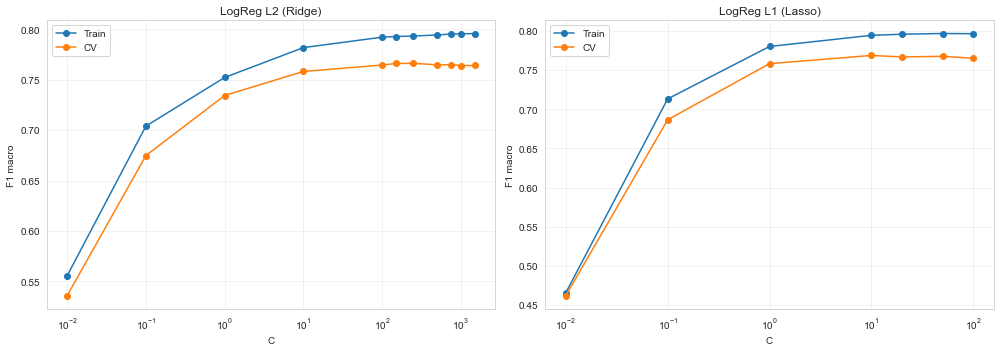

In [21]:
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# L2
results_l2 = grid_l2_1.cv_results_

C_l2 = np.array(results_l2['param_C'], dtype=float)

axes[0].plot(
    C_l2,
    results_l2['mean_train_score'],
    marker='o',
    label='Train'
)

axes[0].plot(
    C_l2,
    results_l2['mean_test_score'],
    marker='o',
    label='CV'
)

axes[0].set_xscale('log')
axes[0].set_xlabel('C')
axes[0].set_ylabel('F1 macro')
axes[0].set_title('LogReg L2 (Ridge)')
axes[0].legend()
axes[0].grid(alpha=0.3)


# L1
results_l1 = grid_l1_1.cv_results_

C_l1 = np.array(results_l1['param_C'], dtype=float)

axes[1].plot(
    C_l1,
    results_l1['mean_train_score'],
    marker='o',
    label='Train'
)

axes[1].plot(
    C_l1,
    results_l1['mean_test_score'],
    marker='o',
    label='CV'
)

axes[1].set_xscale('log')
axes[1].set_xlabel('C')
axes[1].set_ylabel('F1 macro')
axes[1].set_title('LogReg L1 (Lasso)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

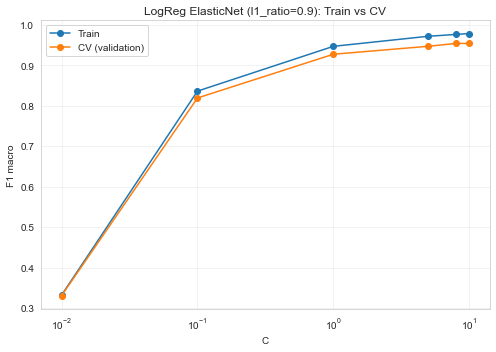

In [22]:
import pandas as pd

results_en = pd.DataFrame(grid_en_1.cv_results_)

best_l1_ratio = grid_en_1.best_params_['l1_ratio']
subset = results_en[results_en['param_l1_ratio'] == best_l1_ratio].sort_values('param_C')

plt.figure(figsize=(7, 5))
plt.plot(subset['param_C'].to_numpy(dtype=float), subset['mean_train_score'].to_numpy(), marker='o', label='Train')
plt.plot(subset['param_C'].to_numpy(dtype=float), subset['mean_test_score'].to_numpy(), marker='o', label='CV (validation)')
plt.xscale('log')
plt.xlabel('C')
plt.ylabel('F1 macro')
plt.title(f'LogReg ElasticNet (l1_ratio={best_l1_ratio}): Train vs CV')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [23]:
from sklearn.metrics import roc_auc_score, log_loss, cohen_kappa_score

best_models_1 = {
    'LogReg_L2_Ridge': grid_l2_1.best_estimator_,
    'LogReg_L1_Lasso': grid_l1_1.best_estimator_,
    'LogReg_ElasticNet': grid_en_1.best_estimator_
}

results_1 = {}
for name, model in best_models_1.items():
    y_pred = model.predict(X_test_1_scaled)
    y_proba = model.predict_proba(X_test_1_scaled)

    acc = accuracy_score(y_test_1, y_pred)
    f1m = f1_score(y_test_1, y_pred, average='macro')
    f1w = f1_score(y_test_1, y_pred, average='weighted')
    roc_auc = roc_auc_score(y_test_1, y_proba, multi_class='ovr', average='macro')
    logloss = log_loss(y_test_1, y_proba)
    kappa = cohen_kappa_score(y_test_1, y_pred)

    results_1[name] = {
        'accuracy': acc,
        'f1_macro': f1m,
        'f1_weighted': f1w,
        'roc_auc': roc_auc,
        'log_loss': logloss,
        'cohen_kappa': kappa
    }

    print(f"{name}: Accuracy={acc:.3f} | F1 macro={f1m:.3f} | F1 weighted={f1w:.3f} | "
          f"ROC-AUC={roc_auc:.3f} | LogLoss={logloss:.3f} | Kappa={kappa:.3f}")

pd.DataFrame(results_1).T.round(3)

LogReg_L2_Ridge: Accuracy=0.804 | F1 macro=0.797 | F1 weighted=0.798 | ROC-AUC=0.938 | LogLoss=0.749 | Kappa=0.771
LogReg_L1_Lasso: Accuracy=0.806 | F1 macro=0.800 | F1 weighted=0.802 | ROC-AUC=0.938 | LogLoss=0.743 | Kappa=0.773
LogReg_ElasticNet: Accuracy=0.950 | F1 macro=0.948 | F1 weighted=0.950 | ROC-AUC=0.997 | LogLoss=0.157 | Kappa=0.941


,accuracy,f1_macro,f1_weighted,roc_auc,log_loss,cohen_kappa
LogReg_L2_Ridge,0.804,0.797,0.798,0.938,0.749,0.771
LogReg_L1_Lasso,0.806,0.800,0.802,0.938,0.743,0.773
LogReg_ElasticNet,0.950,0.948,0.950,0.997,0.157,0.941


**Что видно.** ElasticNet заметно обгоняет L2 и L1. Но причина не обязательно в типе штрафа: `liblinear` решает задачу
по схеме One-vs-Rest (7 независимых бинарных моделей), а `saga` - как одну multinomial-модель с softmax.
Для 7 упорядоченных и частично пересекающихся по BMI классов раздельные бинарные границы описывают структуру хуже.

Чтобы сравнивать именно регуляризации, переобучаем все три модели на одном solver `saga` с одинаковым `max_iter`.

In [24]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_l2_1 = GridSearchCV(
    LogisticRegression(penalty='l2', solver='saga', max_iter=MAX_ITER, random_state=42),
    {'C': [0.01, 0.1, 1, 10, 100, 150, 250, 500, 750, 1000, 1500, 1750, 2000, 2250, 2500]}, cv=cv, scoring='f1_macro', n_jobs=-1, return_train_score=True
).fit(X_train_1_scaled, y_train_1)

grid_l1_1 = GridSearchCV(
    LogisticRegression(penalty='l1', solver='saga', max_iter=MAX_ITER, random_state=42),
    {'C': [0.01, 0.1, 1, 10, 20, 50, 100]}, cv=cv, scoring='f1_macro', n_jobs=-1, return_train_score=True
).fit(X_train_1_scaled, y_train_1)

grid_en_1 = GridSearchCV(
    LogisticRegression(penalty='elasticnet', solver='saga', max_iter=MAX_ITER, random_state=42),
    {'C': [0.01, 0.1, 1, 5, 8, 10, 100, 200, 500, 750, 1000, 1500], 'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]}, cv=cv, scoring='f1_macro', n_jobs=-1, return_train_score=True
).fit(X_train_1_scaled, y_train_1)


print("L2 Ridge:", grid_l2_1.best_params_, round(grid_l2_1.best_score_, 3))
print("L1 Lasso:", grid_l1_1.best_params_, round(grid_l1_1.best_score_, 3))
print("ElasticNet:", grid_en_1.best_params_, round(grid_en_1.best_score_, 3))

L2 Ridge: {'C': 1500} 0.954
L1 Lasso: {'C': 10} 0.957
ElasticNet: {'C': 100, 'l1_ratio': 0.9} 0.954


In [25]:
# Проверка сходимости: если n_iter_ упёрся в max_iter, модель недообучена и сравнение нечестное
def check_convergence(grids):
    for name, g in grids.items():
        n_iter = int(np.max(g.best_estimator_.n_iter_))
        status = 'сошлась' if n_iter < MAX_ITER else 'НЕ СОШЛАСЬ — увеличить max_iter'
        print(f'{name:11s} n_iter = {n_iter:5d} / {MAX_ITER}  → {status}')

check_convergence({'L2': grid_l2_1, 'L1': grid_l1_1, 'ElasticNet': grid_en_1})

L2          n_iter =  2849 / 5000  → сошлась
L1          n_iter =  2683 / 5000  → сошлась
ElasticNet  n_iter =  2697 / 5000  → сошлась


In [26]:
from sklearn.metrics import roc_auc_score, log_loss, cohen_kappa_score

best_models_1 = {
    'LogReg_L2_Ridge': grid_l2_1.best_estimator_,
    'LogReg_L1_Lasso': grid_l1_1.best_estimator_,
    'LogReg_ElasticNet': grid_en_1.best_estimator_
}

results_1 = {}
for name, model in best_models_1.items():
    y_pred = model.predict(X_test_1_scaled)
    y_proba = model.predict_proba(X_test_1_scaled)

    acc = accuracy_score(y_test_1, y_pred)
    f1m = f1_score(y_test_1, y_pred, average='macro')
    f1w = f1_score(y_test_1, y_pred, average='weighted')
    roc_auc = roc_auc_score(y_test_1, y_proba, multi_class='ovr', average='macro')
    logloss = log_loss(y_test_1, y_proba)
    kappa = cohen_kappa_score(y_test_1, y_pred)

    results_1[name] = {
        'accuracy': acc,
        'f1_macro': f1m,
        'f1_weighted': f1w,
        'roc_auc': roc_auc,
        'log_loss': logloss,
        'cohen_kappa': kappa
    }

    print(f"{name}: Accuracy={acc:.3f} | F1 macro={f1m:.3f} | F1 weighted={f1w:.3f} | "
          f"ROC-AUC={roc_auc:.3f} | LogLoss={logloss:.3f} | Kappa={kappa:.3f}")

pd.DataFrame(results_1).T.round(3)

LogReg_L2_Ridge: Accuracy=0.967 | F1 macro=0.965 | F1 weighted=0.966 | ROC-AUC=0.997 | LogLoss=0.178 | Kappa=0.961
LogReg_L1_Lasso: Accuracy=0.964 | F1 macro=0.963 | F1 weighted=0.964 | ROC-AUC=0.998 | LogLoss=0.133 | Kappa=0.958
LogReg_ElasticNet: Accuracy=0.964 | F1 macro=0.963 | F1 weighted=0.964 | ROC-AUC=0.997 | LogLoss=0.169 | Kappa=0.958


,accuracy,f1_macro,f1_weighted,roc_auc,log_loss,cohen_kappa
LogReg_L2_Ridge,0.967,0.965,0.966,0.997,0.178,0.961
LogReg_L1_Lasso,0.964,0.963,0.964,0.998,0.133,0.958
LogReg_ElasticNet,0.964,0.963,0.964,0.997,0.169,0.958


### Сравнение на кросс-валидации

Тестовая выборка — около 420 строк, одна ошибка меняет F1 примерно на 0.002–0.003. Поэтому вывод о том, какая модель
лучше, делаем по кросс-валидации на одних и тех же фолдах и сравниваем разницу между моделями с разбросом между фолдами.

In [27]:
def cv_compare(models, X_tr, y_tr, X_te, y_te):
    # Среднее и разброс F1 macro по одним и тем же фолдам + F1 на отложенном тесте
    rows, folds = [], {}
    for name, model in models.items():
        sc = cross_validate(model, X_tr, y_tr, cv=cv, scoring='f1_macro')['test_score']
        folds[name] = sc
        rows.append({'модель': name,
                     'CV f1_macro': round(float(sc.mean()), 4),
                     'std по фолдам': round(float(sc.std()), 4),
                     'min фолд': round(float(sc.min()), 4),
                     'max фолд': round(float(sc.max()), 4),
                     'test f1_macro': round(float(f1_score(y_te, model.predict(X_te), average='macro')), 4)})
    table = pd.DataFrame(rows).set_index('модель')
    spread = max(s.std() for s in folds.values())
    gap = table['CV f1_macro'].max() - table['CV f1_macro'].min()
    print(f'Разброс между фолдами (макс. std): {spread:.4f}')
    print(f'Разница лучшая − худшая модель:    {gap:.4f}')
    print('→', 'разница НЕ превышает разброс между фолдами: модели неразличимы'
          if gap <= spread else 'разница больше разброса между фолдами')
    print(f"Макс. расхождение CV и test: {(table['CV f1_macro'] - table['test f1_macro']).abs().max():.4f}")
    return table, folds

reg_compare_1, fold_scores_1 = cv_compare(best_models_1, X_train_1_scaled, y_train_1,
                                          X_test_1_scaled, y_test_1)
display(reg_compare_1)

Разброс между фолдами (макс. std): 0.0110
Разница лучшая − худшая модель:    0.0030
→ разница НЕ превышает разброс между фолдами: модели неразличимы
Макс. расхождение CV и test: 0.0107


,CV f1_macro,std по фолдам,min фолд,max фолд,test f1_macro
модель,,,,,
LogReg_L2_Ridge,0.9545,0.0110,0.9383,0.9715,0.9652
LogReg_L1_Lasso,0.9575,0.0108,0.9471,0.9774,0.9632
LogReg_ElasticNet,0.9545,0.0110,0.9383,0.9715,0.9626


In [28]:
# Где оказались лучшие C: на краю сетки — значит, оптимум может быть за её пределами
def check_grid_edge(grids):
    for name, g in grids.items():
        grid_C = sorted({float(p['C']) for p in g.cv_results_['params']})
        c = float(g.best_params_['C'])
        edge = '  ← КРАЙ СЕТКИ' if c in (grid_C[0], grid_C[-1]) else ''
        print(f'{name:11s} C = {c:g} (сетка {grid_C[0]:g} … {grid_C[-1]:g}){edge}')

check_grid_edge({'L2': grid_l2_1, 'L1': grid_l1_1, 'ElasticNet': grid_en_1})

L2          C = 1500 (сетка 0.01 … 2500)
L1          C = 10 (сетка 0.01 … 100)
ElasticNet  C = 100 (сетка 0.01 … 1500)


**Вывод по гипотезам 1 и 3** 
Основной прирост в первом запуске дал переход от One-vs-Rest (liblinear) к multinomial (saga), а не тип регуляризации. На liblinear у L2 и L1 F1 macro на тесте ≈ 0.80, на saga ≈ 0.965, то есть на уровне ElasticNet.
При одинаковом solver и max_iter разница между лучшей и худшей регуляризацией на кросс-валидации - 0.003 (L1: 0.9575, L2 и ElasticNet: 0.9545). Стандартное отклонение по фолдам - около 0.011, то есть разница в 3–4 раза меньше разброса, а сами значения F1 на разных фолдах колеблются от 0.938 до 0.977. Гипотезы 1 и 3 не подтверждаются: на этих данных тип регуляризации не влияет на качество классификации. Это ожидаемо: признаков мало (20), а класс почти полностью задаётся парой Height + Weight.
Единственное устойчивое отличие - у L1 заметно ниже log loss (0.133 против 0.169 у ElasticNet и 0.178 у L2): её вероятности лучше откалиброваны. Кроме того, она зануляет часть коэффициентов, поэтому модель проще. Если выбирать одну логистическую регрессию, разумно взять L1, но не потому, что она точнее.
Лучшие C лежат внутри сетки (проверено расширением диапазона): L2 - 1500, ElasticNet - 100, L1 - 10. При C = 1500 штраф L2 почти не действует, то есть лучшей оказалась практически нерегуляризованная модель: данных достаточно, признаков мало, и переобучаться модели не на чем. L1 оптимальна при более сильном штрафе (C = 10), но и при нём качество то же, а часть коэффициентов уже обнулена. Значит, эти признаки можно убрать без потерь.
Гипотеза 4: максимальное расхождение CV и теста - 0.011, это в пределах разброса между фолдами. Оценки согласованы, признаков переобучения нет.

In [29]:
for name in ['LogReg_L1_Lasso', 'LogReg_ElasticNet']:
    coef = best_models_1[name].coef_
    n_zero = (coef == 0).sum()
    n_total = coef.size
    print(f"{name}: занулено {n_zero} из {n_total} ({n_zero/n_total*100:.1f}%)")

LogReg_L1_Lasso: занулено 35 из 140 (25.0%)
LogReg_ElasticNet: занулено 11 из 140 (7.9%)


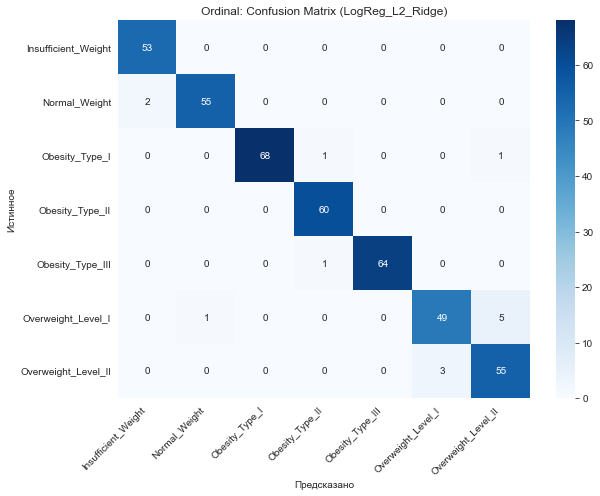

                     precision    recall  f1-score   support

Insufficient_Weight       0.96      1.00      0.98        53
      Normal_Weight       0.98      0.96      0.97        57
     Obesity_Type_I       1.00      0.97      0.99        70
    Obesity_Type_II       0.97      1.00      0.98        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.94      0.89      0.92        55
Overweight_Level_II       0.90      0.95      0.92        58

           accuracy                           0.97       418
          macro avg       0.97      0.97      0.97       418
       weighted avg       0.97      0.97      0.97       418



In [30]:
best_name_1 = max(results_1, key=lambda k: results_1[k]['f1_macro'])
best_model_1 = best_models_1[best_name_1]
y_pred_best_1 = best_model_1.predict(X_test_1_scaled)

cm_1 = confusion_matrix(y_test_1, y_pred_best_1)
plt.figure(figsize=(9, 7))
sns.heatmap(cm_1, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_target.classes_, yticklabels=le_target.classes_)
plt.title(f'Ordinal: Confusion Matrix ({best_name_1})')
plt.xlabel('Предсказано'); plt.ylabel('Истинное')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(classification_report(y_test_1, y_pred_best_1, target_names=le_target.classes_))

## Гипотеза 6: отбор признаков

Чтобы сравнивать именно наборы признаков, а не модели, отбор встроен в `Pipeline` вместе со скейлером
и логистической регрессией. Число признаков `k` подбирается в `GridSearchCV` вместе с `C`; solver и `max_iter`
те же, что у полной модели. Поэтому здесь используются немасштабированные `X_train_1` — масштабирование внутри пайплайна.

In [31]:
NUM_COLS = ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE', 'BMI']

def num_in(X):
    # числовые столбцы, которые есть в данной таблице (для ColumnTransformer)
    return [c for c in NUM_COLS if c in X.columns]

def make_pipe(selector=None, penalty='l2', C=1.0):
    steps = [('pre', ColumnTransformer([('num', StandardScaler(), num_in)], remainder='passthrough'))]
    if selector is not None:
        steps.append(('sel', selector))
    steps.append(('clf', LogisticRegression(penalty=penalty, C=C, solver='saga',
                                            max_iter=MAX_ITER, random_state=RANDOM_STATE)))
    return Pipeline(steps)

C_GRID = [0.01, 0.1, 1, 10, 100, 1000]

def search_k(X_tr, y_tr):
    k_grid = sorted({5, 8, 10, 15, X_tr.shape[1]})
    g = GridSearchCV(make_pipe(SelectKBest(f_classif)), {'sel__k': k_grid, 'clf__C': C_GRID},
                     cv=cv, scoring='f1_macro', n_jobs=-1).fit(X_tr, y_tr)
    res = (pd.DataFrame(g.cv_results_)
             .sort_values('mean_test_score', ascending=False)
             .groupby('param_sel__k')[['mean_test_score', 'std_test_score']].first().round(4))
    res.index.name = 'k признаков'
    print('Лучшее:', g.best_params_, '| CV f1 =', round(g.best_score_, 4))
    return g, res

def top_k_features(X_tr, y_tr, k=10):
    p = Pipeline(make_pipe(SelectKBest(f_classif, k=k)).steps[:2]).fit(X_tr, y_tr)
    names = p.named_steps['pre'].get_feature_names_out()[p.named_steps['sel'].get_support()]
    return [n.split('__', 1)[-1] for n in names]

grid_k_1, res_k_1 = search_k(X_train_1, y_train_1)
display(res_k_1)

chosen_1 = top_k_features(X_train_1, y_train_1, k=10)
print('ANOVA топ-10:', chosen_1)
print('Height в отборе:', 'Height' in chosen_1, '| Weight в отборе:', 'Weight' in chosen_1)

Лучшее: {'clf__C': 1000, 'sel__k': 10} | CV f1 = 0.9622


,mean_test_score,std_test_score
k признаков,,
5,0.7256,0.0207
8,0.8833,0.1054
10,0.9622,0.0110
15,0.9582,0.0100
20,0.9538,0.0111


ANOVA топ-10: ['Age', 'Height', 'Weight', 'FCVC', 'Gender', 'CALC', 'FAVC', 'family_history_with_overweight', 'CAEC', 'MTRANS_Automobile']
Height в отборе: True | Weight в отборе: True


In [32]:
# ANOVA оценивает признаки по одному; RFE и L1-отбор — совместно, в контексте остальных признаков
selectors = {
    'ANOVA (по одному), k=10': SelectKBest(f_classif, k=10),
    'RFE (совместно), k=10':   RFE(LogisticRegression(solver='saga', max_iter=MAX_ITER,
                                                      random_state=RANDOM_STATE),
                                   n_features_to_select=10),
    'L1-отбор (совместно)':    SelectFromModel(LogisticRegression(penalty='l1', C=1, solver='saga',
                                                                  max_iter=MAX_ITER,
                                                                  random_state=RANDOM_STATE)),
    'без отбора':              None,
}
best_C_1 = grid_k_1.best_params_['clf__C']
rows = []
for name, sel in selectors.items():
    sc = cross_validate(make_pipe(sel, C=best_C_1), X_train_1, y_train_1,
                        cv=cv, scoring='f1_macro')['test_score']
    rows.append({'способ отбора': name, 'CV f1_macro': round(float(sc.mean()), 4),
                 'std': round(float(sc.std()), 4)})
display(pd.DataFrame(rows).set_index('способ отбора'))

,CV f1_macro,std
способ отбора,,
"ANOVA (по одному), k=10",0.9622,0.0110
"RFE (совместно), k=10",0.9640,0.0087
L1-отбор (совместно),0.9558,0.0103
без отбора,0.9538,0.0111


In [33]:
# Почему рост по отдельности «неинформативен», а в паре с весом — главный признак
print('F-статистика ANOVA (каждый признак отдельно):')
print(pd.Series(f_classif(X_train_1[['Weight', 'Height', 'Age']], y_train_1)[0],
                index=['Weight', 'Height', 'Age']).round(1))
for cols in (['Weight'], ['Height'], ['Height', 'Weight']):
    sc = cross_validate(make_pipe(), X_train_1[cols], y_train_1, cv=cv, scoring='f1_macro')['test_score']
    print(f'{str(cols):22s} CV f1 = {sc.mean():.3f} ± {sc.std():.3f}')

F-статистика ANOVA (каждый признак отдельно):
Weight    1553.8
Height      29.3
Age         55.7
dtype: float64
['Weight']             CV f1 = 0.458 ± 0.039
['Height']             CV f1 = 0.146 ± 0.026
['Height', 'Weight']   CV f1 = 0.889 ± 0.024


**Вывод по гипотезе 6.** При одинаковом solver и подборе `k` внутри кросс-валидации модель на 10 признаках не хуже модели на всех 20 (F1 macro 0.962 ± 0.011 против 0.954 ± 0.011, разница меньше разброса между фолдами). **Гипотеза подтверждается: половина признаков не нужна.** Способ отбора значения не имеет: ANOVA (0.962), RFE (0.964) и L1-отбор (0.956) неразличимы. При k = 5 и k = 8 качество падает (0.73 и 0.88, у k = 8 большой разброс между фолдами — std 0.105).

По F-статистике ANOVA рост занимает низкое место (F = 29 против 1554 у веса; он ниже даже возраста, у которого F = 56). Логистическая регрессия на одном росте даёт F1 = 0.146, то есть уровень случайного угадывания для 7 классов (≈ 0.14), на одном весе — 0.458, а на паре рост + вес - 0.889. Рост бесполезен сам по себе, но вместе с весом задаёт BMI. Поэтому одномерный отбор (ANOVA) ставит его низко и при малом `k` может отбросить — это прямо видно ниже, на one-hot кодировании. При этом даже на паре линейная модель уступает дереву на готовом BMI (0.948): отношение Weight / Height² она построить не может. Проверим это в разделе про нелинейные модели.

## Гипотеза 2: порядковое кодирование против one-hot

Повторяем те же эксперименты, закодировав CAEC и CALC через one-hot. На `liblinear` картина та же, что и для
порядкового кодирования (OvR проигрывает multinomial), поэтому сразу обучаем на `saga`.

In [34]:
df_onehot = df.copy()
df_onehot = pd.get_dummies(
    df_onehot,
    columns=['CAEC', 'CALC', 'MTRANS'],
    prefix=['CAEC', 'CALC', 'MTRANS']
)

print(df_onehot.columns.tolist())
df_onehot.head()

['Age', 'Gender', 'Height', 'Weight', 'FAVC', 'FCVC', 'NCP', 'SCC', 'SMOKE', 'CH2O', 'family_history_with_overweight', 'FAF', 'TUE', 'NObeyesdad', 'NObeyesdad_encoded', 'CAEC_Always', 'CAEC_Frequently', 'CAEC_Sometimes', 'CAEC_no', 'CALC_Always', 'CALC_Frequently', 'CALC_Sometimes', 'CALC_no', 'MTRANS_Automobile', 'MTRANS_Bike', 'MTRANS_Motorbike', 'MTRANS_Public_Transportation', 'MTRANS_Walking']


,Age,Gender,Height,Weight,FAVC,FCVC,NCP,SCC,SMOKE,CH2O,...,CAEC_no,CALC_Always,CALC_Frequently,CALC_Sometimes,CALC_no,MTRANS_Automobile,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking
0,21.0,0,1.62,64.0,0,2.0,3.0,0,0,2.0,...,False,False,False,False,True,False,False,False,True,False
1,21.0,0,1.52,56.0,0,3.0,3.0,1,1,3.0,...,False,False,False,True,False,False,False,False,True,False
2,23.0,1,1.80,77.0,0,2.0,3.0,0,0,2.0,...,False,False,True,False,False,False,False,False,True,False
3,27.0,1,1.80,87.0,0,3.0,3.0,0,0,2.0,...,False,False,True,False,False,False,False,False,False,True
4,22.0,1,1.78,89.8,0,2.0,1.0,0,0,2.0,...,False,False,False,True,False,False,False,False,True,False


In [35]:
X_1 = df_onehot.drop(columns=['NObeyesdad', 'NObeyesdad_encoded'], errors='ignore')
y_1 = df_onehot['NObeyesdad_encoded']  

print(X_1.shape, y_1.shape)
print(X_1.dtypes)  

(2087, 26) (2087,)
Age                               float64
Gender                              int32
Height                            float64
Weight                            float64
FAVC                                int32
FCVC                              float64
NCP                               float64
SCC                                 int32
SMOKE                               int32
CH2O                              float64
family_history_with_overweight      int32
FAF                               float64
TUE                               float64
CAEC_Always                          bool
CAEC_Frequently                      bool
CAEC_Sometimes                       bool
CAEC_no                              bool
CALC_Always                          bool
CALC_Frequently                      bool
CALC_Sometimes                       bool
CALC_no                              bool
MTRANS_Automobile                    bool
MTRANS_Bike                          bool
MTRANS_Motorbik

In [36]:
from sklearn.model_selection import train_test_split

X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(
    X_1, y_1,
    test_size=0.2,
    stratify=y_1,
    random_state=42
)

print("Train:", X_train_2.shape, "Test:", X_test_2.shape)
print(y_train_2.value_counts(normalize=True).round(3))
print(y_test_2.value_counts(normalize=True).round(3))

Train: (1669, 26) Test: (418, 26)
NObeyesdad_encoded
2    0.168
4    0.155
3    0.142
6    0.139
1    0.135
5    0.132
0    0.128
Name: proportion, dtype: float64
NObeyesdad_encoded
2    0.167
4    0.156
3    0.144
6    0.139
1    0.136
5    0.132
0    0.127
Name: proportion, dtype: float64


In [37]:
from sklearn.preprocessing import StandardScaler

numeric_cols = ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']

scaler_2 = StandardScaler()
X_train_2_scaled = X_train_2.copy()
X_test_2_scaled = X_test_2.copy()

X_train_2_scaled[numeric_cols] = scaler_2.fit_transform(X_train_2[numeric_cols])
X_test_2_scaled[numeric_cols] = scaler_2.transform(X_test_2[numeric_cols])

In [38]:
grid_l2_2 = GridSearchCV(
    LogisticRegression(penalty='l2', solver='saga', max_iter=MAX_ITER, random_state=42),
    {'C': [0.01, 0.1, 1, 10, 100, 1000, 1500, 4000, 6000]}, cv=cv, scoring='f1_macro', n_jobs=-1, return_train_score=True
).fit(X_train_2_scaled, y_train_2)

grid_l1_2 = GridSearchCV(
    LogisticRegression(penalty='l1', solver='saga', max_iter=MAX_ITER, random_state=42),
    {'C': [0.01, 0.1, 1, 10, 20, 50, 100]}, cv=cv, scoring='f1_macro', n_jobs=-1, return_train_score=True
).fit(X_train_2_scaled, y_train_2)

grid_en_2 = GridSearchCV(
    LogisticRegression(penalty='elasticnet', solver='saga', max_iter=MAX_ITER, random_state=42),
    {'C': [0.01, 0.1, 1, 5, 8, 10, 100], 'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]}, cv=cv, scoring='f1_macro', n_jobs=-1, return_train_score=True
).fit(X_train_2_scaled, y_train_2)

print("L2 Ridge:", grid_l2_2.best_params_, round(grid_l2_2.best_score_, 3))
print("L1 Lasso:", grid_l1_2.best_params_, round(grid_l1_2.best_score_, 3))
print("ElasticNet:", grid_en_2.best_params_, round(grid_en_2.best_score_, 3))

L2 Ridge: {'C': 100} 0.954
L1 Lasso: {'C': 20} 0.956
ElasticNet: {'C': 10, 'l1_ratio': 0.9} 0.955


In [39]:
check_convergence({'L2': grid_l2_2, 'L1': grid_l1_2, 'ElasticNet': grid_en_2})
check_grid_edge({'L2': grid_l2_2, 'L1': grid_l1_2, 'ElasticNet': grid_en_2})

L2          n_iter =  1390 / 5000  → сошлась
L1          n_iter =  2702 / 5000  → сошлась
ElasticNet  n_iter =  1343 / 5000  → сошлась
L2          C = 100 (сетка 0.01 … 6000)
L1          C = 20 (сетка 0.01 … 100)
ElasticNet  C = 10 (сетка 0.01 … 100)


In [40]:
best_models_2 = {
    'LogReg_L2_Ridge': grid_l2_2.best_estimator_,
    'LogReg_L1_Lasso': grid_l1_2.best_estimator_,
    'LogReg_ElasticNet': grid_en_2.best_estimator_
}

results_2 = {}
for name, model in best_models_2.items():
    y_pred = model.predict(X_test_2_scaled)
    y_proba = model.predict_proba(X_test_2_scaled)

    acc = accuracy_score(y_test_2, y_pred)
    f1m = f1_score(y_test_2, y_pred, average='macro')
    f1w = f1_score(y_test_2, y_pred, average='weighted')
    roc_auc = roc_auc_score(y_test_2, y_proba, multi_class='ovr', average='macro')
    logloss = log_loss(y_test_2, y_proba)
    kappa = cohen_kappa_score(y_test_2, y_pred)

    results_2[name] = {
        'accuracy': acc,
        'f1_macro': f1m,
        'f1_weighted': f1w,
        'roc_auc': roc_auc,
        'log_loss': logloss,
        'cohen_kappa': kappa
    }

    print(f"{name}: Accuracy={acc:.3f} | F1 macro={f1m:.3f} | F1 weighted={f1w:.3f} | "
          f"ROC-AUC={roc_auc:.3f} | LogLoss={logloss:.3f} | Kappa={kappa:.3f}")

pd.DataFrame(results_2).T.round(3)

LogReg_L2_Ridge: Accuracy=0.952 | F1 macro=0.952 | F1 weighted=0.952 | ROC-AUC=0.998 | LogLoss=0.152 | Kappa=0.944
LogReg_L1_Lasso: Accuracy=0.976 | F1 macro=0.975 | F1 weighted=0.976 | ROC-AUC=0.998 | LogLoss=0.120 | Kappa=0.972
LogReg_ElasticNet: Accuracy=0.962 | F1 macro=0.961 | F1 weighted=0.962 | ROC-AUC=0.998 | LogLoss=0.137 | Kappa=0.955


,accuracy,f1_macro,f1_weighted,roc_auc,log_loss,cohen_kappa
LogReg_L2_Ridge,0.952,0.952,0.952,0.998,0.152,0.944
LogReg_L1_Lasso,0.976,0.975,0.976,0.998,0.120,0.972
LogReg_ElasticNet,0.962,0.961,0.962,0.998,0.137,0.955


In [41]:
lasso_model_2 = best_models_2['LogReg_L1_Lasso']
n_zero = (lasso_model_2.coef_ == 0).sum()
n_total = lasso_model_2.coef_.size
print(f"L1 (One-Hot) занулила {n_zero} из {n_total} коэффициентов ({n_zero/n_total*100:.1f}%)")

# какие именно признаки
zero_mask = (lasso_model_2.coef_ == 0).all(axis=0)
zero_features = X_train_2_scaled.columns[zero_mask]
print("Полностью обнулённые признаки:", list(zero_features))

L1 (One-Hot) занулила 53 из 182 коэффициентов (29.1%)
Полностью обнулённые признаки: ['CALC_Always']


In [42]:
coef = lasso_model_2.coef_  # shape (7, 26)
zero_counts = (coef == 0).sum(axis=0)  # для каждого признака — в скольких из 7 классов коэффициент = 0

zero_summary = pd.Series(zero_counts, index=X_train_2_scaled.columns).sort_values(ascending=False)
print(zero_summary[zero_summary > 0])

CALC_Always                       7
MTRANS_Motorbike                  5
MTRANS_Bike                       5
SMOKE                             4
CAEC_Frequently                   4
MTRANS_Walking                    3
SCC                               3
CH2O                              3
CALC_Sometimes                    3
CAEC_no                           3
MTRANS_Automobile                 2
CAEC_Sometimes                    1
MTRANS_Public_Transportation      1
CALC_no                           1
CALC_Frequently                   1
Age                               1
TUE                               1
FAF                               1
family_history_with_overweight    1
NCP                               1
FAVC                              1
CAEC_Always                       1
dtype: int32


In [43]:
for name in ['LogReg_L1_Lasso', 'LogReg_ElasticNet']:
    coef = best_models_2[name].coef_
    n_zero = (coef == 0).sum()
    n_total = coef.size
    print(f"{name}: занулено {n_zero} из {n_total} ({n_zero/n_total*100:.1f}%)")

LogReg_L1_Lasso: занулено 53 из 182 (29.1%)
LogReg_ElasticNet: занулено 52 из 182 (28.6%)


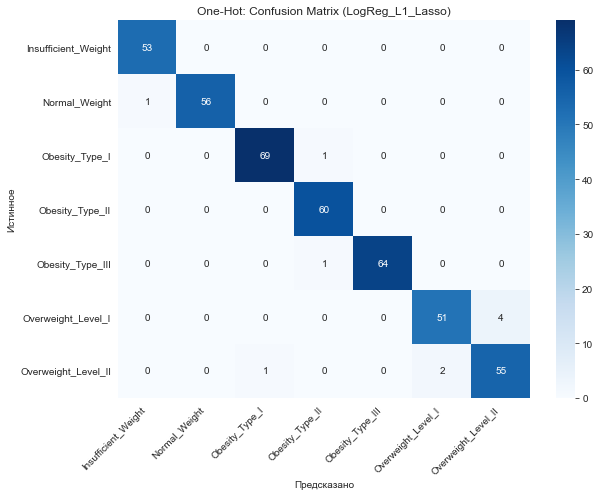

                     precision    recall  f1-score   support

Insufficient_Weight       0.98      1.00      0.99        53
      Normal_Weight       1.00      0.98      0.99        57
     Obesity_Type_I       0.99      0.99      0.99        70
    Obesity_Type_II       0.97      1.00      0.98        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.96      0.93      0.94        55
Overweight_Level_II       0.93      0.95      0.94        58

           accuracy                           0.98       418
          macro avg       0.98      0.98      0.98       418
       weighted avg       0.98      0.98      0.98       418



In [44]:
best_name_2 = max(results_2, key=lambda k: results_2[k]['f1_macro'])
best_model_2 = best_models_2[best_name_2]
y_pred_best_2 = best_model_2.predict(X_test_2_scaled)

cm_2 = confusion_matrix(y_test_2, y_pred_best_2)
plt.figure(figsize=(9, 7))
sns.heatmap(cm_2, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_target.classes_, yticklabels=le_target.classes_)
plt.title(f'One-Hot: Confusion Matrix ({best_name_2})')
plt.xlabel('Предсказано'); plt.ylabel('Истинное')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(classification_report(y_test_2, y_pred_best_2, target_names=le_target.classes_))

In [45]:
reg_compare_2, fold_scores_2 = cv_compare(best_models_2, X_train_2_scaled, y_train_2,
                                          X_test_2_scaled, y_test_2)
display(reg_compare_2)

Разброс между фолдами (макс. std): 0.0127
Разница лучшая − худшая модель:    0.0016
→ разница НЕ превышает разброс между фолдами: модели неразличимы
Макс. расхождение CV и test: 0.0198


,CV f1_macro,std по фолдам,min фолд,max фолд,test f1_macro
модель,,,,,
LogReg_L2_Ridge,0.9540,0.0127,0.9409,0.9716,0.9516
LogReg_L1_Lasso,0.9556,0.0051,0.9471,0.9619,0.9754
LogReg_ElasticNet,0.9552,0.0122,0.9380,0.9714,0.9614


In [46]:
# Отбор признаков на one-hot — тем же способом
grid_k_2, res_k_2 = search_k(X_train_2, y_train_2)
display(res_k_2)
chosen_2 = top_k_features(X_train_2, y_train_2, k=10)
print('ANOVA топ-10:', chosen_2)
print('Height в отборе:', 'Height' in chosen_2, '| Weight в отборе:', 'Weight' in chosen_2)

Лучшее: {'clf__C': 1000, 'sel__k': 15} | CV f1 = 0.9619


,mean_test_score,std_test_score
k признаков,,
5,0.7159,0.0170
8,0.7286,0.0318
10,0.7627,0.0209
15,0.9619,0.0044
26,0.9540,0.0127


ANOVA топ-10: ['Age', 'Weight', 'FCVC', 'Gender', 'FAVC', 'family_history_with_overweight', 'CAEC_Frequently', 'CAEC_Sometimes', 'CALC_Sometimes', 'CALC_no']
Height в отборе: False | Weight в отборе: True


**Отбор признаков на one-hot.** Здесь топ-10 по ANOVA даёт всего F1 = 0.763 против 0.962 на порядковом кодировании. Причина — `Height` не попадает в топ-10: dummy-признаки CAEC и CALC по отдельности сильнее связаны с классом и вытесняют рост. При k = 15 рост возвращается в отбор, и качество восстанавливается до 0.962. Это прямо подтверждает вывод по гипотезе 6: результат одномерного отбора зависит не от числа признаков, а от того, сохранится ли пара Height + Weight.

,Ordinal,Ordinal std,OneHot,OneHot std
модель,,,,
LogReg_L2_Ridge,0.9545,0.0110,0.9540,0.0127
LogReg_L1_Lasso,0.9575,0.0108,0.9556,0.0051
LogReg_ElasticNet,0.9545,0.0110,0.9552,0.0122


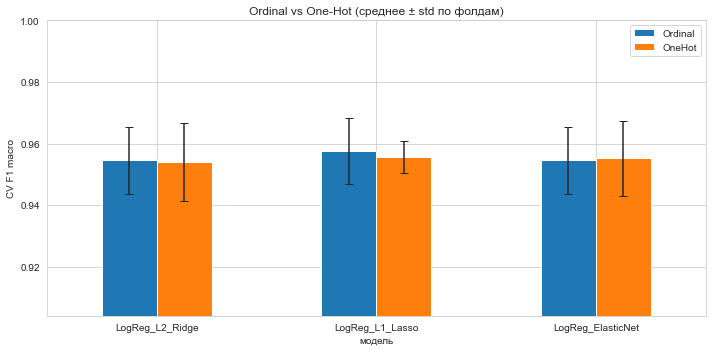

In [47]:
# Ordinal vs One-Hot по кросс-валидации: среднее ± std по фолдам
enc = pd.DataFrame({
    'Ordinal': reg_compare_1['CV f1_macro'], 'Ordinal std': reg_compare_1['std по фолдам'],
    'OneHot':  reg_compare_2['CV f1_macro'], 'OneHot std':  reg_compare_2['std по фолдам'],
})
display(enc)

ax = enc[['Ordinal', 'OneHot']].plot(kind='bar', yerr=enc[['Ordinal std', 'OneHot std']].values.T,
                                     capsize=4, figsize=(10, 5), rot=0)
ax.set_ylabel('CV F1 macro'); ax.set_title('Ordinal vs One-Hot (среднее ± std по фолдам)')
ax.set_ylim(enc[['Ordinal', 'OneHot']].min().min() - 0.05, 1)
plt.tight_layout(); plt.show()

**Вывод по гипотезе 2** 
Порядковое кодирование использует 20 признаков, one-hot - 26. Разница в CV F1 между кодированиями не превышает 0.002 при разбросе по фолдам около 0.011: гипотеза подтверждается, более компактное порядковое кодирование не хуже one-hot. Типы регуляризации на one-hot также неразличимы (разница 0.0016).

L1 на one-hot зануляет 29% коэффициентов. Признак CALC_Always занулён полностью: эта категория встречается в данных всего 1 раз. Чаще всего зануляются и другие редкие категории (MTRANS_Motorbike, MTRANS_Bike) и SMOKE (курят около 2%). Это согласуется с их малой информативностью.

На отложенном тесте L1 на one-hot показала F1 = 0.975 - лучший результат среди всех моделей. Но на кросс-валидации её качество 0.956, как у остальных. Одно разбиение на 418 объектов может дать разницу около 0.02 просто за счёт удачного состава теста, поэтому модели сравниваются по кросс-валидации.

## Нелинейные модели и признак BMI

Логистическая регрессия линейна по признакам и не может сама построить отношение Weight / Height².
Деревья и ансамбли могут приблизить его ступеньками. Сравним подходы на одних и тех же фолдах —
на исходных признаках и с добавленным BMI.

CV f1_macro             std        
признаки             без BMI   с BMI без BMI   с BMI
модель                                              
LogReg L2 (saga)      0.9545  0.9493  0.0110  0.0112
Бустинг               0.9633  0.9862  0.0060  0.0044
Дерево (d=7)          0.8818  0.9665  0.0084  0.0067
Случайный лес         0.9425  0.9856  0.0111  0.0075

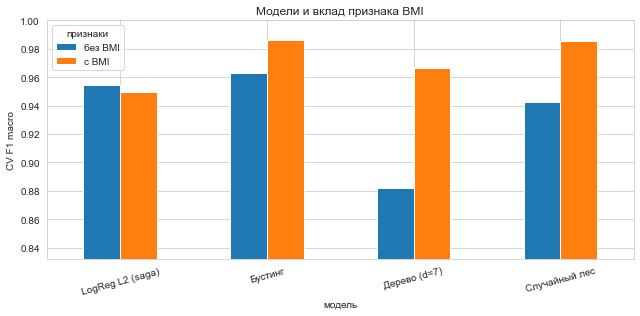

In [48]:
X_train_1_bmi = X_train_1.assign(BMI=X_train_1['Weight'] / X_train_1['Height'] ** 2)
X_test_1_bmi  = X_test_1.assign(BMI=X_test_1['Weight'] / X_test_1['Height'] ** 2)

models = {
    'LogReg L2 (saga)': make_pipe(C=float(grid_l2_1.best_params_['C'])),
    'Дерево (d=7)':     DecisionTreeClassifier(max_depth=7, random_state=RANDOM_STATE),
    'Случайный лес':    RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
    'Бустинг':          HistGradientBoostingClassifier(random_state=RANDOM_STATE),
}

rows = []
for name, model in models.items():
    for tag, Xtr in (('без BMI', X_train_1), ('с BMI', X_train_1_bmi)):
        sc = cross_validate(model, Xtr, y_train_1, cv=cv, scoring='f1_macro')['test_score']
        rows.append({'модель': name, 'признаки': tag,
                     'CV f1_macro': round(float(sc.mean()), 4), 'std': round(float(sc.std()), 4)})
model_long = pd.DataFrame(rows)
model_compare = model_long.pivot(index='модель', columns='признаки', values='CV f1_macro')[['без BMI', 'с BMI']]
display(model_long.pivot(index='модель', columns='признаки', values=['CV f1_macro', 'std']))

ax = model_compare.plot(kind='bar', figsize=(9, 4.5), rot=15)
ax.set_ylabel('CV F1 macro'); ax.set_title('Модели и вклад признака BMI')
ax.set_ylim(model_compare.min().min() - 0.05, 1)
plt.tight_layout(); plt.show()

**Вывод** 
Признак BMI резко улучшает модели на деревьях: одиночное дерево - с 0.882 до 0.967, случайный лес - с 0.943 до 0.986, градиентный бустинг - с 0.963 до 0.986. Деревья делят пространство признаков только порогами по одному признаку и без BMI вынуждены приближать кривую Weight / Height² «лесенкой» из многих разбиений. С готовым BMI достаточно нескольких порогов.

Логистической регрессии BMI не помогает (0.955 → 0.949, в пределах разброса между фолдами). Вероятно, в узком диапазоне роста в данных BMI хорошо приближается линейной комбинацией веса и роста, и эта информация у линейной модели уже была. Её ограничение - в нечётких границах соседних классов.

Лучшее качество в работе - у случайного леса и бустинга с признаком BMI: F1 macro = 0.986 ± 0.004 (бустинг) и 0.986 ± 0.008 (лес). Это на 0.03 выше лучшей логистической регрессии, в 3 раза больше разброса между фолдами. Без BMI бустинг и логистическая регрессия неразличимы. Основное преимущество нелинейных моделей - способность использовать отношение веса к росту.

## Гипотеза 7: подбор гиперпараметров ансамблей

Выше лес и бустинг обучались с параметрами по умолчанию, а у логистической регрессии `C` подбирался по сетке —
сравнение было не совсем равным. Подбираем гиперпараметры обоих ансамблей (с признаком BMI) случайным поиском
по кросс-валидации на тех же фолдах.

**Гипотеза 7:** подбор гиперпараметров даст прирост F1 больше разброса между фолдами.

Оценка `best_score_` после поиска немного оптимистична: из многих комбинаций выбрана лучшая на тех же фолдах.
Поэтому окончательная, независимая проверка выбранной модели — на отложенном тесте в конце работы.

In [49]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.base import clone

search_spaces = {
    'Бустинг': (HistGradientBoostingClassifier(random_state=RANDOM_STATE), {
        'learning_rate':     [0.03, 0.05, 0.1, 0.2],
        'max_iter':          [100, 200, 400],
        'max_depth':         [None, 3, 5, 8],
        'min_samples_leaf':  [5, 10, 20, 40],
        'l2_regularization': [0.0, 0.1, 1.0],
    }),
    'Случайный лес': (RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1), {
        'max_depth':         [None, 10, 20],
        'min_samples_leaf':  [1, 2, 5],
        'max_features':      ['sqrt', 0.5, None],
    }),
}

searches = {}
for name, (est, space) in search_spaces.items():
    searches[name] = RandomizedSearchCV(est, space, n_iter=25, cv=cv, scoring='f1_macro',
                                        n_jobs=-1, random_state=RANDOM_STATE).fit(X_train_1_bmi, y_train_1)
    print(f'{name}: лучшие параметры {searches[name].best_params_}')

# Сравнение «по умолчанию» и «после подбора» на одних и тех же фолдах
candidates = {
    'Бустинг (по умолчанию)':       HistGradientBoostingClassifier(random_state=RANDOM_STATE),
    'Бустинг (подбор)':             searches['Бустинг'].best_estimator_,
    'Случайный лес (по умолчанию)': RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
    'Случайный лес (подбор)':       searches['Случайный лес'].best_estimator_,
}
rows, tuned_folds = [], {}
for name, model in candidates.items():
    sc = cross_validate(clone(model), X_train_1_bmi, y_train_1, cv=cv, scoring='f1_macro')['test_score']
    tuned_folds[name] = sc
    rows.append({'модель': name, 'CV f1_macro': round(float(sc.mean()), 4), 'std': round(float(sc.std()), 4)})
tune_compare = pd.DataFrame(rows).set_index('модель')
display(tune_compare)

for base in ('Бустинг', 'Случайный лес'):
    d = tuned_folds[f'{base} (подбор)'].mean() - tuned_folds[f'{base} (по умолчанию)'].mean()
    s = max(tuned_folds[f'{base} (подбор)'].std(), tuned_folds[f'{base} (по умолчанию)'].std())
    print(f'{base}: прирост от подбора {d:+.4f} при разбросе по фолдам {s:.4f} →',
          'больше разброса' if d > s else 'в пределах разброса')

# Итоговая модель: лучшая по CV; при равенстве в пределах разброса берём более простую (по умолчанию)
best_name = tune_compare['CV f1_macro'].idxmax()
default_name = best_name.replace('(подбор)', '(по умолчанию)')
if best_name != default_name and \
   tuned_folds[best_name].mean() - tuned_folds[default_name].mean() <=    max(tuned_folds[best_name].std(), tuned_folds[default_name].std()):
    best_name = default_name
final_name, final_estimator = best_name, candidates[best_name]
print('\nИтоговая модель:', final_name)

Бустинг: лучшие параметры {'min_samples_leaf': 40, 'max_iter': 400, 'max_depth': 3, 'learning_rate': 0.2, 'l2_regularization': 0.0}
Случайный лес: лучшие параметры {'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': None}


,CV f1_macro,std
модель,,
Бустинг (по умолчанию),0.9862,0.0044
Бустинг (подбор),0.9874,0.0051
Случайный лес (по умолчанию),0.9856,0.0075
Случайный лес (подбор),0.9862,0.0071


Бустинг: прирост от подбора +0.0013 при разбросе по фолдам 0.0051 → в пределах разброса
Случайный лес: прирост от подбора +0.0006 при разбросе по фолдам 0.0075 → в пределах разброса

Итоговая модель: Бустинг (по умолчанию)


**Вывод по гипотезе 7** 
После подбора гиперпараметров бустинг даёт F1 macro = 0.987 ± 0.005 (по умолчанию - 0.986 ± 0.004), случайный лес - 0.986 ± 0.007 (по умолчанию - 0.986 ± 0.008). Прирост - 0.0013 и 0.0006 при разбросе по фолдам 0.005–0.008. Гипотеза не подтверждается: параметры по умолчанию уже близки к оптимуму. Потолок качества задаёт не модель, а сами данные: оставшиеся ошибки сосредоточены у размытых границ классов около порогов BMI. Поскольку подбор не дал значимого прироста, итоговой выбрана более простая модель - бустинг с параметрами по умолчанию.

## Что дают признаки образа жизни без роста и веса

Рост и вес вместе задают BMI, а по нему выставлена метка, поэтому высокие метрики выше объясняются в первую очередь ими.
Проверим, насколько класс предсказывается **только** по пищевым привычкам, активности, транспорту, полу и возрасту.

In [50]:
X_life = X_train_1.drop(columns=['Height', 'Weight'])
print('Признаков без роста и веса:', X_life.shape[1])

rows = []
for name, model in (('LogReg L2 (saga)', make_pipe(C=1.0)),
                    ('Случайный лес',    RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1)),
                    ('Бустинг',          HistGradientBoostingClassifier(random_state=RANDOM_STATE))):
    sc = cross_validate(model, X_life, y_train_1, cv=cv, scoring='f1_macro')['test_score']
    rows.append({'модель': name, 'CV f1_macro': round(float(sc.mean()), 4), 'std': round(float(sc.std()), 4)})
life_compare = pd.DataFrame(rows).set_index('модель')
display(life_compare)
print('Для сравнения — случайное угадывание для 7 классов: F1 ≈ 0.14')

Признаков без роста и веса: 18


,CV f1_macro,std
модель,,
LogReg L2 (saga),0.5480,0.0429
Случайный лес,0.8503,0.0112
Бустинг,0.8342,0.0293


Для сравнения — случайное угадывание для 7 классов: F1 ≈ 0.14


In [51]:
display(pd.crosstab(df['NObeyesdad'], df['Gender']).reindex(order))   # Gender: 0 = Female, 1 = Male
for col in ['FCVC', 'NCP', 'FAF', 'TUE', 'CH2O']:
    print(f'{col}: доля дробных значений = {(df[col] % 1 != 0).mean():.0%}')

Gender,0,1
NObeyesdad,,
Insufficient_Weight,169,98
Normal_Weight,137,145
Overweight_Level_I,145,131
Overweight_Level_II,103,187
Obesity_Type_I,156,195
Obesity_Type_II,2,295
Obesity_Type_III,323,1


FCVC: доля дробных значений = 40%
NCP: доля дробных значений = 31%
FAF: доля дробных значений = 58%
TUE: доля дробных значений = 55%
CH2O: доля дробных значений = 62%


## Вывод по признакам, оценивающим образ жизни
Без роста и веса случайный лес даёт F1 macro = 0.850 ± 0.011, бустинг - 0.834 ± 0.029, логистическая регрессия - 0.548 ± 0.043 (случайное угадывание ≈ 0.14, с ростом и весом - 0.986). Высокий результат деревьев, однако, объясняется особенностями датасета, а не связью образа жизни с ожирением.

Пол почти однозначно определяет два класса: Obesity_Type_II — 295 мужчин из 297, Obesity_Type_III - 323 женщины из 324. В реальной популяции такого разделения нет; это артефакт генерации данных.
Следы синтетики: у 31–62% строк дробные ответы на анкетные вопросы с целыми вариантами (FCVC, NCP, FAF, TUE, CH2O). Интерполированные значения образуют «отпечаток» класса, который находят деревья, но не линейная модель. Этим объясняется разрыв 0.85 против 0.55.

Поэтому оценка предсказательной силы образа жизни на этих данных завышена. На реальных анкетах она, скорее всего, заметно ниже.

## Гипотеза 5: качество по классам

Средние классы шкалы (Normal_Weight, Overweight_Level_I, Overweight_Level_II) граничат с соседями с обеих сторон
и узкие по BMI, поэтому ожидаем у них F1 ниже, чем у крайних (Insufficient_Weight, Obesity_Type_III).
Считаем F1 по классам на предсказаниях кросс-валидации лучшей логистической регрессии - это все 1600+ train-объектов,
а не 60 тестовых на класс.

In [52]:
best_reg = max(fold_scores_1, key=lambda k: fold_scores_1[k].mean())
print('Модель:', best_reg)
y_cv_pred = cross_val_predict(best_models_1[best_reg], X_train_1_scaled, y_train_1, cv=cv)

names_true = le_target.inverse_transform(y_train_1)
names_pred = le_target.inverse_transform(y_cv_pred)

rep = pd.DataFrame(classification_report(names_true, names_pred, output_dict=True, zero_division=0)).T
per_class = rep.loc[order, ['precision', 'recall', 'f1-score', 'support']].round(3)
display(per_class)

middle = ['Normal_Weight', 'Overweight_Level_I', 'Overweight_Level_II']
edges = ['Insufficient_Weight', 'Obesity_Type_III']
f1_mid, f1_edge = per_class.loc[middle, 'f1-score'].mean(), per_class.loc[edges, 'f1-score'].mean()
print(f'Средний F1, средние классы: {f1_mid:.3f}')
print(f'Средний F1, крайние классы: {f1_edge:.3f}')


Модель: LogReg_L1_Lasso


,precision,recall,f1-score,support
Insufficient_Weight,0.945,0.972,0.959,214.0
Normal_Weight,0.944,0.902,0.923,225.0
Overweight_Level_I,0.904,0.932,0.918,221.0
Overweight_Level_II,0.943,0.935,0.939,232.0
Obesity_Type_I,0.986,0.975,0.980,281.0
Obesity_Type_II,0.987,0.987,0.987,237.0
Obesity_Type_III,0.992,1.000,0.996,259.0


Средний F1, средние классы: 0.927
Средний F1, крайние классы: 0.978


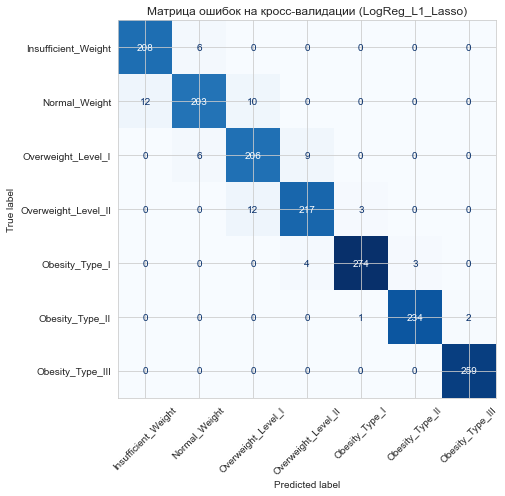

Ошибок: 68, из них между соседними классами: 68 (100%)


In [53]:
fig, ax = plt.subplots(figsize=(8, 7))
ConfusionMatrixDisplay.from_predictions(names_true, names_pred, labels=order, cmap='Blues',
                                        xticks_rotation=45, colorbar=False, ax=ax)
ax.set_title(f'Матрица ошибок на кросс-валидации ({best_reg})')
plt.tight_layout(); plt.show()

# Какая доля ошибок приходится на СОСЕДНИЕ по шкале классы
pos = {c: i for i, c in enumerate(order)}
err = [(pos[t], pos[p]) for t, p in zip(names_true, names_pred) if t != p]
if err:
    near = sum(abs(a - b) == 1 for a, b in err)
    print(f'Ошибок: {len(err)}, из них между соседними классами: {near} ({100 * near / len(err):.0f}%)')

**Вывод по гипотезе 5** 
Средний F1 у средних классов (Normal, Overweight I–II) - 0.927, у крайних (Insufficient, Obesity III) - 0.978. Гипотеза подтверждается. Но причина не только в соседях с двух сторон: Obesity_Type_I и Obesity_Type_II тоже имеют двух соседей, а их F1 - 0.980 и 0.987. Решающим оказывается ширина класса по BMI. Классы ожирения занимают около 5 единиц BMI, а Overweight_Level_I и II - около 2.5 единиц каждый, и граница между ними (BMI ≈ 27) не совпадает со стандартными порогами. Худший класс - Overweight_Level_I (F1 = 0.918).

Все 68 ошибок на кросс-валидации (100%) приходятся на соседние по шкале классы: модель ошибается только около границ BMI и никогда не путает далёкие классы.

## Итоговая модель на отложенном тесте

Модели выше сравнивались по кросс-валидации на train. Итоговую модель, выбранную после подбора гиперпараметров,
обучаем на всём train и один раз проверяем на отложенном тесте, который до этого в выборе модели не участвовал.

Итоговая модель (Бустинг (по умолчанию)) на тесте: F1 macro = 0.983 | accuracy = 0.983
                     precision    recall  f1-score   support

Insufficient_Weight       1.00      0.98      0.99        53
      Normal_Weight       0.98      1.00      0.99        57
     Obesity_Type_I       0.99      0.99      0.99        70
    Obesity_Type_II       0.97      1.00      0.98        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       1.00      0.95      0.97        55
Overweight_Level_II       0.95      0.98      0.97        58

           accuracy                           0.98       418
          macro avg       0.98      0.98      0.98       418
       weighted avg       0.98      0.98      0.98       418



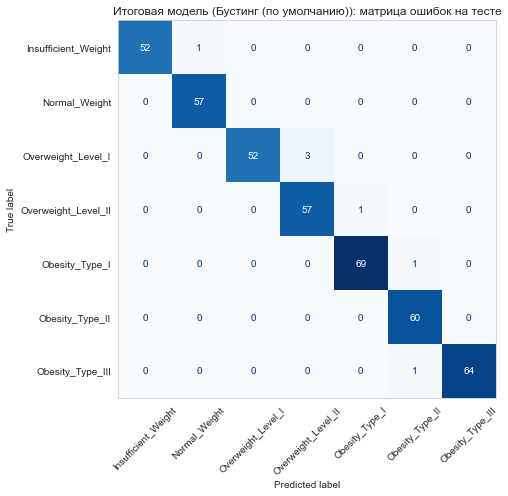

In [54]:
final_model = clone(final_estimator).fit(X_train_1_bmi, y_train_1)
y_pred_final = final_model.predict(X_test_1_bmi)

print(f"Итоговая модель ({final_name}) на тесте: F1 macro = {f1_score(y_test_1, y_pred_final, average='macro'):.3f} "
      f"| accuracy = {accuracy_score(y_test_1, y_pred_final):.3f}")
print(classification_report(y_test_1, y_pred_final, target_names=le_target.classes_))

fig, ax = plt.subplots(figsize=(8, 7))
ConfusionMatrixDisplay.from_predictions(le_target.inverse_transform(y_test_1),
                                        le_target.inverse_transform(y_pred_final),
                                        labels=order, cmap='Blues', colorbar=False,
                                        xticks_rotation=45, ax=ax)
ax.set_title(f'Итоговая модель ({final_name}): матрица ошибок на тесте')
ax.grid(False)
plt.tight_layout(); plt.show()

**Вывод.** На отложенном тесте итоговая модель (градиентный бустинг с параметрами по умолчанию) даёт F1 macro = 0.983, accuracy = 0.983. CV-оценка - 0.986 ± 0.004, так что результат на тесте согласуется с кросс-валидацией и выбор модели не переобучен под фолды. Самые трудные классы по-прежнему Overweight_Level_I и II (F1 = 0.97), у логистической регрессии на тесте было 0.92.

## Итоги

| # | Гипотеза | Результат |
|---|---|---|
| 1 | L2 лучше L1 | **Не подтверждена.** При одинаковом solver (`saga`) и `max_iter` CV F1 macro: L1 - 0.958, L2 - 0.955. Разница 0.003 при разбросе по фолдам ≈ 0.011 - модели неразличимы |
| 2 | Ordinal не хуже one-hot | **Подтверждена.** Разница между кодированиями ≤ 0.002 для всех трёх регуляризаций; порядковое кодирование компактнее (20 признаков против 26) |
| 3 | ElasticNet лучше L1 и L2 | **Не подтверждена.** Преимущество ElasticNet в первом запуске (0.95 против 0.80 на тесте) объяснялось не регуляризацией, а разницей One-vs-Rest (`liblinear`) и multinomial (`saga`). На одном solver все три неразличимы |
| 4 | CV согласуется с тестом | **Подтверждена.** Расхождение CV и теста ≤ 0.02 для всех моделей; итоговая модель: 0.986 на CV и 0.983 на тесте. Одно разбиение на 418 объектов само даёт разброс до 0.02, поэтому модели сравниваются по CV |
| 5 | Средние классы хуже крайних | **Подтверждена с уточнением.** Средний F1: 0.927 у Normal / Overweight I–II против 0.978 у крайних. Решает не число соседей, а ширина класса по BMI: Obesity I–II тоже «средние», но широкие (≈ 5 единиц BMI) и имеют F1 0.98–0.99; узкие Overweight I–II (≈ 2.5 единицы) - худшие. 100% ошибок - между соседними классами |
| 6 | Топ-10 признаков не хуже всех | **Подтверждена при условии.** На порядковом кодировании 10 признаков дают 0.962 против 0.954 у всех 20. На one-hot топ-10 по ANOVA даёт лишь 0.763: рост вытесняется dummy-признаками; при k = 15 рост возвращается и качество восстанавливается (0.962). Решающее условие - в отборе должны быть и Height, и Weight |
| 7 | Подбор гиперпараметров ансамблей даст прирост | **Не подтверждена.** Бустинг: 0.986 → 0.987, лес: 0.986 → 0.986; прирост ≤ 0.0013 при разбросе по фолдам 0.005–0.008 — параметры по умолчанию уже близки к оптимуму |

**Главное**

1. **Класс почти полностью определяется индексом массы тела.** Одно дерево решений на признаке BMI даёт F1 macro = 0.948, на одном весе - 0.663, а логистическая регрессия на одном росте - 0.146 (уровень случайного угадывания). Рост бесполезен сам по себе, но вместе с весом задаёт BMI.
2. **В линейных моделях самый большой эффект дала схема многоклассовой классификации, а не регуляризация:** переход от One-vs-Rest (`liblinear`) к multinomial (`saga`) поднял F1 с ≈ 0.80 до ≈ 0.96.
3. **Тип регуляризации и способ кодирования на качество не влияют** - различия в пределах разброса между фолдами. Оптимальная регуляризация слабая (L2: C = 1500); L1 при той же точности даёт лучше откалиброванные вероятности (log loss 0.133 против 0.17–0.18) и зануляет признаки редких категорий.
4. **Лучшая модель — градиентный бустинг с признаком BMI**: CV F1 macro = 0.986 ± 0.004, на отложенном тесте - 0.983. Случайный лес с BMI неразличим с ним (0.986 ± 0.008), подбор гиперпараметров не дал прироста сверх разброса между фолдами, поэтому выбрана модель с параметрами по умолчанию. Отрыв ансамблей от лучшей логистической регрессии (0.955) - около 0.03, в 3 раза больше разброса между фолдами. BMI критичен для моделей на деревьях (одиночное дерево: 0.882 → 0.967), но не помогает логистической регрессии (0.955 → 0.949).
5. **Без роста и веса деревья дают F1 macro до 0.850, но это заслуга артефактов датасета, а не образа жизни.** Obesity_Type_II почти целиком мужской (295 из 297), Obesity_Type_III почти целиком женский (323 из 324), а у 31–62% строк анкетные ответы дробные - следы синтетической генерации. Линейная модель на тех же признаках даёт лишь 0.548.

**Ограничения**

* 77% объектов сгенерированы синтетически (SMOTE). Синтетика оставляет следы - дробные ответы на анкетные вопросы с целыми вариантами и почти полное совпадение пола с классами Obesity_Type_II и III, - поэтому высокие метрики, скорее всего, переоценивают качество на реальных анкетах.
* Метка фактически выставлена по BMI, поэтому задача в основном сводится к восстановлению формулы по росту и весу. Граница между Overweight_Level_I и II (BMI ≈ 27) задана авторами датасета и не совпадает со стандартными порогами ВОЗ.
* Гиперпараметры ансамблей подбирались случайным поиском по той же кросс-валидации, поэтому CV-оценка после подбора немного оптимистична; независимая оценка — отложенный тест. Анализ ошибок по классам (гипотеза 5) сделан для лучшей линейной модели.
* 24 полных дубликата удалены до разбиения на train и test (2111 → 2087 строк).